# H-002 · 1D vs 1H after costs

**Universe from `UNIVERSE_STAR` (currently E). No 4H.** Do not fetch, cache, or simulate 4-hour bars.

Compare locked pairs under the H-001 trad-z OLS book: same per-fill `COSTS`, close-`t` signal → fill open `t+1`.
z / HL lookbacks stay session-scaled (`60/252` days × 6 hourly bars). **OLS hedge is 1 quarter of sessions** (`OLS_HEDGE_SESSIONS = 63`).

Sample: longest Yahoo 1H window (~730d). **Both arms share the same calendar session days** — trim 1D (and 1H) to the intersection of trading days present in both panels, not two separate windows. Full-IS scoreboard on the first 70% of those shared days; walk-forward folds for stability boxplots; one sealed OOS look on the last 30% after locking `BAR_STAR`.

**Primary metric:** full-IS **net** Sharpe (gross beside it for friction). Metrics reuse the star-tearsheet stack (`gross_returns_from_net` → `oos_headline_metrics` → `cvar`).

After locking `BAR_STAR`:
- `"1d"` → later hyps use full universe 1D with `RESEARCH_IS_END` for that universe
- `"1h"` → later hyps stay on this window with 70/30 IS:OOS


## Checklist (delete after reading)

**Keep / decide with:** full-IS net Sharpe, gross Sharpe (cost gap), max DD, Calmar, CVaR 5%, `corr_to_s1`, cost bps/year, n trades; fold boxplots for stability; ops (A1 4/24 daily paper fits `1d`).

**Removed as noise:** `median_sharpe_hint`, entries/HL bar charts, full `fold_df` dump (`pct_z_finite` / DSR-local with N=1), stale Universe-C copy.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.diagnosis import plotly_bar_size_trade_compare
from backtest.s2_coint.report import (
    bar_size_decision_table,
    fold_val_metrics,
    load_star_stack,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    BARS_PER_SESSION_1H,
    DEFAULT_STAR_STACK,
    config_from_stack,
    frozen_pairs_for_universe,
    load_s1_weekly,
    load_universe_panels,
    lookbacks_for_bar,
    n_trials_local,
    n_trials_stack,
    overlay_ols_hedge,
    register_hypothesis_arms,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))

# OLS hedge window in trading sessions. 63 ≈ 1 quarter. Change this to change
# 1D and 1H OLS together (1h bars = this × BARS_PER_SESSION_1H).
OLS_HEDGE_SESSIONS = 63


def h002_lookbacks(bar: str) -> dict:
    lb = dict(lookbacks_for_bar(bar))
    scale = BARS_PER_SESSION_1H if bar == "1h" else 1
    lb["ols_window"] = OLS_HEDGE_SESSIONS * scale
    return lb


print("STAR_PATH", STAR_PATH)
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)
print(
    "OLS_HEDGE_SESSIONS",
    OLS_HEDGE_SESSIONS,
    "1d ols",
    h002_lookbacks("1d")["ols_window"],
    "1h ols",
    h002_lookbacks("1h")["ols_window"],
)



STAR_PATH C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json
UNIVERSE E PAIRS ['CCI|AMT', 'SBAC|CCI', 'SBRA|VTR', 'NNN|O', 'NNN|WPC', 'PLD|TRNO']
OLS_HEDGE_SESSIONS 63 1d ols 63 1h ols 378


## 1. Load frozen 1D panel and fetch 1H (no 4H)


In [2]:
from data.ingestion.equity_fetcher import (
    YFINANCE_1H_MAX_CALENDAR_DAYS,
    fetch_ohlcv,
    yfinance_1h_min_start,
)
from data.processing.s2_coint_store import build_pair_panel
from backtest.s2_coint.research import (
    align_panels_to_common_sessions,
    long_ohlcv_to_frames,
    overlap_is_end,
    pair_tuples,
    unique_tickers,
)

assert "4h" not in ("1d", "1h")
train_1d, full_1d = load_universe_panels(UNIVERSE, "1d", PAIRS_STAR, root=ROOT)
tickers = unique_tickers(PAIRS_STAR)
print("tickers", tickers)

# Yahoo 1h wall is 730 calendar days (not bars). Exact end-730 is rejected
# (inclusive lookback + yfinance exclusive end). Helper uses end-(730-2).
START_1H = yfinance_1h_min_start()
print(
    "1h fetch start",
    START_1H.date(),
    "wall",
    YFINANCE_1H_MAX_CALENDAR_DAYS,
    "calendar days",
)
frames_1h = {}
for t in tickers:
    long = fetch_ohlcv(t, START_1H, interval="1h", isAsian=True)
    print(
        t,
        "1h rows",
        len(long),
        "min",
        long["date"].min() if len(long) else None,
        "max",
        long["date"].max() if len(long) else None,
    )
    frames_1h.update(long_ohlcv_to_frames(long))

lb_1h = h002_lookbacks("1h")
lb_1d = h002_lookbacks("1d")
panel_1h = build_pair_panel(
    frames_1h,
    pair_tuples(PAIRS_STAR),
    ols_window=lb_1h["ols_window"],
    z_window=lb_1h["z_window"],
    hl_window=lb_1h["hl_window"],
    include_adf_pvalue=True,
    include_variance_jump=True,
    hedge="ols",
)
# Same window: keep only calendar days present in BOTH panels (trim 1d to the
# 1h sample's session set, and drop 1h days missing from 1d).
panel_1d_ov, panel_1h_ov, common_days = align_panels_to_common_sessions(
    full_1d, panel_1h
)
panel_1d_ov = overlay_ols_hedge(
    panel_1d_ov,
    ols_window=lb_1d["ols_window"],
    z_window=lb_1d["z_window"],
    hl_window=lb_1d["hl_window"],
)
n_sess_1d = pd.to_datetime(panel_1d_ov["date"]).dt.normalize().nunique()
n_sess_1h = pd.to_datetime(panel_1h_ov["date"]).dt.normalize().nunique()
print(
    "common sessions",
    common_days.min().date(),
    "→",
    common_days.max().date(),
    "n_days",
    len(common_days),
    "1d rows",
    len(panel_1d_ov),
    "1h rows",
    len(panel_1h_ov),
    "1d sess",
    n_sess_1d,
    "1h sess",
    n_sess_1h,
)
assert n_sess_1d == n_sess_1h == len(common_days)

data_dir = os.path.join(ROOT, "01_data", "data_files", "s2_coint")
os.makedirs(data_dir, exist_ok=True)
panel_1h_path = os.path.join(data_dir, f"s2_panel_{UNIVERSE}_1h_full.parquet")
panel_1h.to_parquet(panel_1h_path, index=False)
print("wrote", panel_1h_path)



tickers ['CCI', 'AMT', 'SBAC', 'SBRA', 'VTR', 'NNN', 'O', 'WPC', 'PLD', 'TRNO']
1h fetch start 2024-09-07 wall 730 calendar days
CCI 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
AMT 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
SBAC 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
SBRA 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
VTR 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
NNN 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
O 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
WPC 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
PLD 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
TRNO 1h rows 3480 min 2024-09-09 13:30:00 max 2026-09-04 19:30:00
overlap 2024-09-09 13:30:00 → 2026-09-04 00:00:00 1d 2994 1h 20838
wrote c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_panel_E_1h_full.parquet


## 2. 70/30 split on the shared session window

Cut on unique **calendar days** shared by both panels (not raw timestamps), so 1d and 1h IS/OOS cover the same trading days.


In [3]:
is_end_ov = overlap_is_end(panel_1d_ov, frac=0.70)
is_1d, oos_1d = split_is_oos(panel_1d_ov, is_end=is_end_ov)
is_1h, oos_1h = split_is_oos(panel_1h_ov, is_end=is_end_ov)
s1_weekly = load_s1_weekly(ROOT)
is_days_1d = pd.to_datetime(is_1d["date"]).dt.normalize().nunique()
is_days_1h = pd.to_datetime(is_1h["date"]).dt.normalize().nunique()
print(
    "overlap IS end",
    is_end_ov.date(),
    "1d IS rows",
    len(is_1d),
    "1h IS rows",
    len(is_1h),
    "IS session days 1d/1h",
    is_days_1d,
    is_days_1h,
)
assert is_days_1d == is_days_1h



overlap IS end 2026-01-30 00:00:00 1d IS 2094 1h IS 14538


## 3. Full-IS decision table (primary)

Run both bars on the **full overlap IS** (not fold-val). Scoreboard via `bar_size_decision_table` → tearsheet `oos_headline_metrics` + `cvar`. **Net Sharpe is the lead column;** gross shows friction. Screen is inconclusive for a hard edge — `BAR_STAR` below is provisional for ops.


In [4]:
HYP_ID = "H-002"
register_hypothesis_arms(HYP_ID, ["1d", "1h"], overwrite=True)
cfg_1d = config_from_stack(stack, bar="1d", ols_window=h002_lookbacks("1d")["ols_window"])
cfg_1h = config_from_stack(stack, bar="1h", ols_window=h002_lookbacks("1h")["ols_window"])
configs_bar = {"1d": cfg_1d, "1h": cfg_1h}
n_loc = n_trials_local(configs_bar)
n_stk = n_trials_stack(HYP_ID, configs_bar)

res_1d = run_s2_backtest(
    is_1d, cfg_1d, s1_weekly=s1_weekly, n_trials_local=n_loc, n_trials_stack=n_stk
)
res_1h = run_s2_backtest(
    is_1h, cfg_1h, s1_weekly=s1_weekly, n_trials_local=n_loc, n_trials_stack=n_stk
)
results_is = {"1d": res_1d, "1h": res_1h}
decision_df = bar_size_decision_table(
    results_is, s1_weekly=s1_weekly, n_trials_local=n_loc, n_trials_stack=n_stk
)
decision_df



,arm,ann_sharpe_net,ann_sharpe_gross,max_drawdown,calmar,cvar_5,corr_to_s1,cost_bps_year,n_trades,n_days
0,1d,0.096951,0.909362,-0.02603,0.071185,-0.003388,-0.213989,181.093410,19,349
1,1h,0.385136,1.054589,-0.02385,0.130267,-0.001874,0.047082,56.286587,41,2423


## 4. Fold stability (boxplots only)

Walk-forward val Sharpe / DD / `corr_to_s1` — **stability, not STAR ranking.**


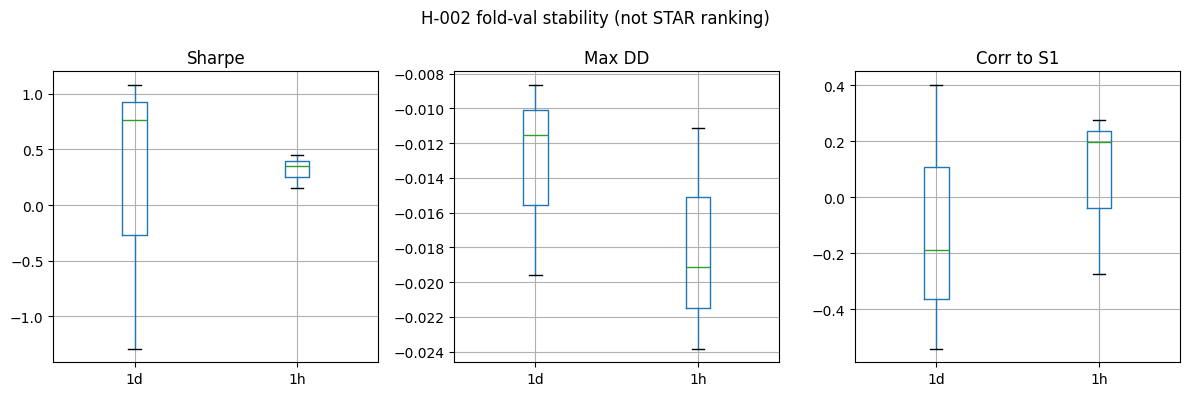

In [5]:
folds_1d = make_s2_folds(
    pd.DatetimeIndex(pd.to_datetime(is_1d["date"])).unique(),
    n_folds=3,
    embargo_bars=embargo_bars_for_config(bar="1d"),
)
folds_1h = make_s2_folds(
    pd.DatetimeIndex(pd.to_datetime(is_1h["date"])).unique(),
    n_folds=3,
    embargo_bars=embargo_bars_for_config(bar="1h"),
)
df_1d = fold_val_metrics(is_1d, folds_1d, {"1d": cfg_1d}, hyp_id=HYP_ID, s1_weekly=s1_weekly)
df_1h = fold_val_metrics(is_1h, folds_1h, {"1h": cfg_1h}, hyp_id=HYP_ID, s1_weekly=s1_weekly)
fold_df = pd.concat([df_1d, df_1h], ignore_index=True)
plot_fold_boxplots(fold_df, title="H-002 fold-val stability (not STAR ranking)")
plt.show()



## 5. Trade comparison (1d vs 1h)

Interactive z + entry/exit markers for one pair at a time (dropdown). Hold stats in **sessions** so hourly and daily are comparable.


In [6]:
fig = plotly_bar_size_trade_compare(
    is_1d,
    is_1h,
    res_1d,
    res_1h,
    pair_ids=PAIRS_STAR,
    title="H-002 full-IS trades",
)
fig.show()



## 6. Lock `BAR_STAR` (provisional)

Metrics above do not clearly prefer either arm. Lock **`1d`** for ops / A1 paper cadence; revisit bar size later (e.g. end of year) if needed. Do not use fold-median argmax.


In [7]:
BAR_STAR = "1d"  # provisional for ops; revisit later — do not use argmax
require_star("BAR_STAR", BAR_STAR)
stack["BAR_STAR"] = BAR_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH, "BAR_STAR", BAR_STAR)



wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json BAR_STAR 1d


## 7. Sealed OOS once (last 30% of overlap)


In [8]:
require_star("BAR_STAR", BAR_STAR)
oos_panel = oos_1d if BAR_STAR == "1d" else oos_1h
oos_cfg = config_from_stack(
    stack, bar=BAR_STAR, ols_window=h002_lookbacks(BAR_STAR)["ols_window"]
)
oos = run_s2_backtest(
    oos_panel,
    oos_cfg,
    s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)
print(oos.metrics)
write_tearsheet_pdf(
    tearsheet_path("H-002", BAR_STAR),
    oos.returns,
    title=f"H-002 {BAR_STAR} sealed OOS",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)



{'ann_sharpe': 0.20677306302554058, 'max_drawdown': -0.0316411453939498, 'n_days': 150, 'psr': 0.0, 'dsr_local': 0.9779376519433096, 'dsr_stack': 0.8575960689586541, 'skew': 0.24502978552094692, 'excess_kurtosis': 1.9356196753562314, 'n_trials_local': 2, 'n_trials_stack': 8, 'corr_to_s1': 0.2900120448451089}


## 8. Sample-rule fork for later hyps

If `BAR_STAR == "1d"`: later notebooks load `s2_panel_{U}_1d_{train,full}.parquet` and cut OOS at that universe's `RESEARCH_IS_END`.

If `BAR_STAR == "1h"`: later notebooks load `s2_panel_{U}_1h_full.parquet` and use a 70/30 split on this overlap window.

H-003 cointegration-break flat rule is next. Never re-open `BAR_STAR` casually.


In [9]:
if BAR_STAR == "1d":
    is_h, _ = split_is_oos(panel_1h_ov, is_end=is_end_ov)
    train_path = os.path.join(data_dir, f"s2_panel_{UNIVERSE}_1h_train.parquet")
    is_h.to_parquet(train_path, index=False)
    print("wrote", train_path)
else:
    print(
        f"1D locked: later hyps use full {UNIVERSE} 1D research IS "
        "(RESEARCH_IS_END for that universe)"
    )



wrote c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_panel_E_1h_train.parquet
